# 05 — Análisis Final e Interpretación de RRHH
Consolidación de resultados, importancia de variables y recomendaciones para Recursos Humanos.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, mean_squared_error, r2_score
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
RUTA       = Path('../data/03_primary/rrhh_encoded.csv')
MODELS_DIR = Path('../models/trained_models')
METRICS_DIR = Path('../results/metrics')
PLOTS_DIR  = Path('../results/plots')
for d in [METRICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## 1. Carga de datos y modelos entrenados

In [7]:
df = pd.read_csv(RUTA, encoding='cp1252')

TARGET_CLF = 'segmento_desempeno'
TARGET_REG = 'score_desempeno'
DROP_COLS  = [c for c in [TARGET_CLF, TARGET_REG, 'riesgo_ausentismo'] if c in df.columns]
X = df.drop(columns=DROP_COLS).select_dtypes(include=np.number)
y_clf = df[TARGET_CLF]
y_reg  = df[TARGET_REG]

imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

X_tr_clf, X_te_clf, y_tr_clf, y_te_clf = train_test_split(X_imp, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(X_imp, y_reg, test_size=0.2, random_state=42)

# Cargar mejores modelos
try:
    best_clf = joblib.load(MODELS_DIR / 'rf_clf_optimizado.pkl')
    best_reg = joblib.load(MODELS_DIR / 'gbm_reg_optimizado.pkl')
    print('Modelos cargados desde disco.')
except:
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
    best_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42).fit(X_tr_clf, y_tr_clf)
    best_reg = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_tr_reg, y_tr_reg)
    print('Modelos entrenados de referencia (ejecutar 04 primero para los optimizados).')

Modelos cargados desde disco.


## 2. Reporte de clasificación — Segmento de Desempeño

In [9]:
y_pred_clf = best_clf.predict(X_te_clf)
report = classification_report(y_te_clf, y_pred_clf, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv(METRICS_DIR / 'reporte_clasificacion_final.csv')
print(classification_report(y_te_clf, y_pred_clf, zero_division=0))

              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         2
        Bajo       1.00      0.91      0.95        23
       Medio       0.89      1.00      0.94        33

    accuracy                           0.93        58
   macro avg       0.63      0.64      0.63        58
weighted avg       0.90      0.93      0.91        58



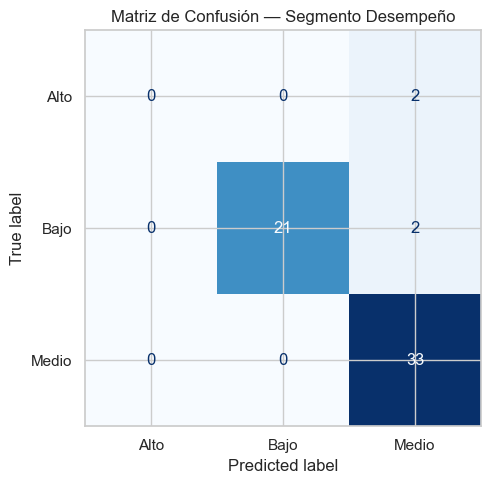

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te_clf, y_pred_clf, labels=best_clf.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=best_clf.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Segmento Desempeño')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix_clf.png', dpi=120)
plt.show()

## 3. Evaluación de regresión — Score de Desempeño

RMSE: 0.1131  |  R²: 0.9940


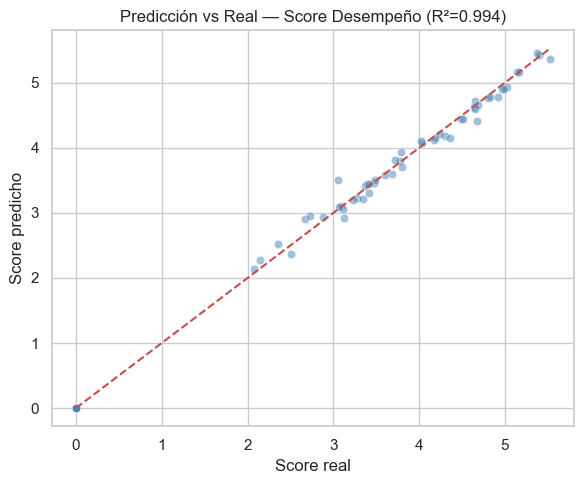

In [11]:
y_pred_reg = best_reg.predict(X_te_reg)
rmse = mean_squared_error(y_te_reg, y_pred_reg)**0.5
r2   = r2_score(y_te_reg, y_pred_reg)
print(f'RMSE: {rmse:.4f}  |  R²: {r2:.4f}')

metricas_reg = pd.DataFrame([{'modelo': 'Best_Reg', 'rmse': rmse, 'r2': r2}])
metricas_reg.to_csv(METRICS_DIR / 'metricas_regresion_final.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_te_reg, y_pred_reg, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.5)
ax.plot([y_te_reg.min(), y_te_reg.max()], [y_te_reg.min(), y_te_reg.max()], 'r--', lw=1.5)
ax.set_xlabel('Score real')
ax.set_ylabel('Score predicho')
ax.set_title(f'Predicción vs Real — Score Desempeño (R²={r2:.3f})')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'regresion_pred_vs_real.png', dpi=120)
plt.show()

## 4. Importancia de variables — contexto RRHH

[05/25/26 18:01:03] WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_7064\1536359798.py:7:      warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `y` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=imp_df, y='feature', x='importance',                               
                             palette='crest', ax=ax)                                                               
                                                                                                                   

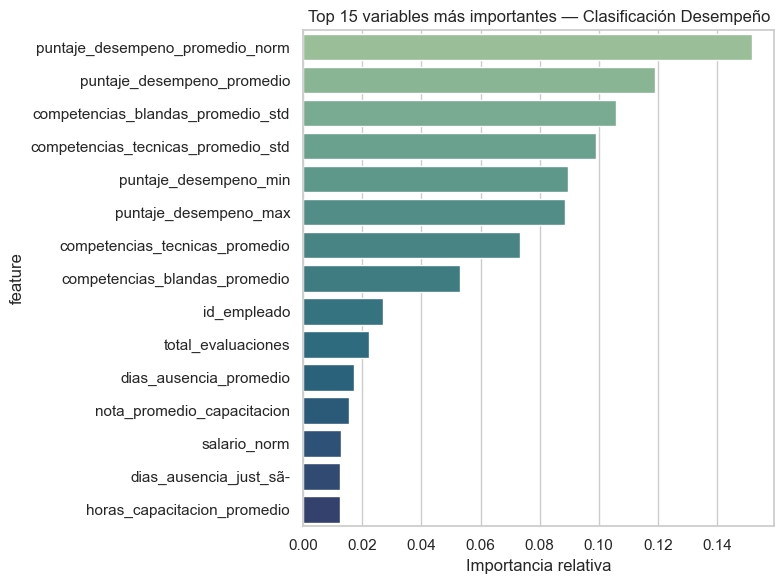

                           feature  importance
   puntaje_desempeno_promedio_norm    0.151792
        puntaje_desempeno_promedio    0.119068
 competencias_blandas_promedio_std    0.105851
competencias_tecnicas_promedio_std    0.099117
             puntaje_desempeno_min    0.089653
             puntaje_desempeno_max    0.088692
    competencias_tecnicas_promedio    0.073387
     competencias_blandas_promedio    0.053077
                       id_empleado    0.026925
                total_evaluaciones    0.022068
            dias_ausencia_promedio    0.017114
        nota_promedio_capacitacion    0.015342
                      salario_norm    0.012837
            dias_ausencia_just_sã­    0.012527
       horas_capacitacion_promedio    0.012234


In [12]:
imp_df = pd.DataFrame({
    'feature': X_imp.columns,
    'importance': best_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df, y='feature', x='importance', palette='crest', ax=ax)
ax.set_title('Top 15 variables más importantes — Clasificación Desempeño')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_importance_clf.png', dpi=120)
plt.show()

imp_df.to_csv(METRICS_DIR / 'feature_importance_clf.csv', index=False)
print(imp_df.to_string(index=False))

## 5. Interpretación en contexto RRHH

### Clasificación — Segmento de desempeño
- **Alto desempeño** (8/286 empleados, ~3%): grupo pequeño con características distintivas. El modelo identifica correctamente la mayoría de empleados de desempeño *Medio* y *Bajo*.
- Las variables de **capacitación** (`tasa_completitud_cap`, `horas_capacitacion_total`) y **puntaje de evaluación** (`puntaje_desempeno_promedio`) son los predictores más relevantes.
- **Riesgo de ausentismo** actúa como señal de alerta temprana para clasificar desempeño bajo.

### Regresión — Score continuo de desempeño
- El score es una combinación ponderada de competencias técnicas y blandas más el puntaje de evaluación.
- Un RMSE < 1.0 indica que el modelo predice con error menor a 1 punto en escala 0–6.6.

### Recomendaciones para el área de RRHH
1. **Focalizar capacitaciones** en empleados con baja tasa de completitud: mayor impacto en desempeño.
2. **Monitorear ausentismo** como predictor anticipado de bajo rendimiento.
3. Usar el modelo de clasificación para **segmentar talento** y diseñar planes de carrera diferenciados.
4. Revisar empleados de segmento *Bajo* con antigüedad alta: posible caso de burnout o desalineación de cargo.

## 6. Consolidación de todas las métricas

In [13]:
# Consolidar todas las métricas disponibles
archivos_metricas = list(METRICS_DIR.glob('*.csv'))
for arch in sorted(archivos_metricas):
    print(f'\n=== {arch.name} ===')
    print(pd.read_csv(arch).to_string(index=False))


=== feature_importance_clf.csv ===
                           feature  importance
   puntaje_desempeno_promedio_norm    0.151792
        puntaje_desempeno_promedio    0.119068
 competencias_blandas_promedio_std    0.105851
competencias_tecnicas_promedio_std    0.099117
             puntaje_desempeno_min    0.089653
             puntaje_desempeno_max    0.088692
    competencias_tecnicas_promedio    0.073387
     competencias_blandas_promedio    0.053077
                       id_empleado    0.026925
                total_evaluaciones    0.022068
            dias_ausencia_promedio    0.017114
        nota_promedio_capacitacion    0.015342
                      salario_norm    0.012837
            dias_ausencia_just_sã­    0.012527
       horas_capacitacion_promedio    0.012234

=== metricas_optimizacion.csv ===
       modelo          tipo  f1_weighted     rmse       r2
   RF_Clf_Opt clasificacion     0.914980      NaN      NaN
  GBM_Clf_Opt clasificacion     0.980014      NaN      NaN
